In [1]:
import jax
import jax.numpy as jnp

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns  

import liesel.model as lsl
import liesel.goose as gs

from tensorflow_probability.substrates.jax.experimental import distributions as tfde
from tensorflow_probability.python.internal.backend.jax.compat import v2 as tf
import tensorflow_probability.substrates.jax.distributions as tfd
import tensorflow_probability.substrates.jax.bijectors as tfb

In [2]:
# ====================
# FACTORY FUNCTIONS
# ====================

def make_wishart(df, scale_tril):
    return tfd.WishartTriL(
        df=df, 
        scale_tril=scale_tril, 
        input_output_cholesky=True, 
        validate_args=False
    )

def make_mvn_precision(loc, precision_factor):
    return tfde.MultivariateNormalPrecisionFactorLinearOperator(
        loc=loc,
        precision_factor=tf.linalg.LinearOperatorLowerTriangular(precision_factor),
        validate_args=False
    )

In [3]:
# ====================
# DATA SIMULATION
# ====================

def simulate_data(seed=42):
    key = jax.random.PRNGKey(seed)
    k1, k2, k3, k4, k5 = jax.random.split(key, 5)
    
    n_units, n_obs_small, n_obs_large, n_alts, n_params = 100, 5, 50, 5, 5 
    n_z = 3 # 1 Intercept + 2 Covariates (e.g., log_income, family_size)
    
    counts = jnp.array([n_obs_small] * 50 + [n_obs_large] * 50)
    unit_idx = jnp.repeat(jnp.arange(n_units), counts)
    
    # Generate Demographics (Z matrix)
    Z_covariates = jax.random.normal(k4, shape=(n_units, n_z - 1)) 
    Z_intercept = jnp.ones((n_units, 1))
    Z = jnp.concatenate([Z_intercept, Z_covariates], axis=1)
    
    # Define True Delta Matrix (n_z x n_params)
    # Row 0: Base means (intercepts & base price slope)
    # Row 1: Effect of Covariate 1
    # Row 2: Effect of Covariate 2
    true_Delta = jnp.array([
        [ 1.0, -1.0,  0.0,  0.0, -3.0], 
        [ 0.5,  0.2, -0.1,  0.0,  0.8], 
        [-0.3,  0.5,  0.2, -0.4,  0.0]  
    ])
    
    # True Variance
    true_Sigma = 3.0 * jnp.eye(n_params)
    true_Sigma = true_Sigma.at[3, 4].set(1.5)
    true_Sigma = true_Sigma.at[4, 3].set(1.5)
    
    # Generate Betas: Beta_i ~ N(Z_i * Delta, Sigma)
    beta_means = jnp.dot(Z, true_Delta)
    beta_dist = tfd.MultivariateNormalFullCovariance(loc=beta_means, covariance_matrix=true_Sigma)
    betas = beta_dist.sample(seed=k1)
    
    X_list, y_list = [], []
    for i in range(n_units):
        n_i, beta_i = counts[i], betas[i]
        k2, sk = jax.random.split(k2)
        price = jax.random.uniform(sk, shape=(n_i, n_alts), minval=-1.5, maxval=0.0)
        
        D = jnp.zeros((n_i, n_alts, n_params))
        for a in range(4): D = D.at[:, a, a].set(1.0)
        D = D.at[:, :, 4].set(price)
        
        logits = jnp.einsum('ijk,k->ij', D, beta_i)
        k3, sk = jax.random.split(k3)
        choices = tfd.Categorical(logits=logits).sample(seed=sk)
        
        X_list.append(D)
        y_list.append(choices)
        
    return {
        "X": jnp.concatenate(X_list, axis=0),
        "y": jnp.concatenate(y_list, axis=0),
        "Z": Z,
        "true_betas": betas,
        "unit_idx": unit_idx,
        "true_Delta": true_Delta,
        "true_Sigma": true_Sigma
    }

# Simulate Data
data = simulate_data()
k_dim = 5
n_units = 100
n_z = 3

print(f"Simulated Data: {n_units} units, {k_dim} parameters, {n_z} demographic variables.")

Simulated Data: 100 units, 5 parameters, 3 demographic variables.


In [4]:
# ====================
# MODEL BUILDING
# ====================

nu_val = float(k_dim + 3)
V_inv_val = jnp.linalg.inv(nu_val * jnp.eye(k_dim))
Vinv_chol_val = jnp.linalg.cholesky(V_inv_val)
A_val = 0.01

# 1. Precision Matrix
sigma_inv_chol = lsl.Var.new_param(
    value=jnp.eye(k_dim),
    distribution=lsl.Dist(make_wishart, df=nu_val, scale_tril=Vinv_chol_val),
    name="sigma_inv_chol"
)

sigma_inv_chol_latent = sigma_inv_chol.transform(
    tfb.FillScaleTriL(diag_bijector=tfb.Exp()), 
    name="sigma_inv_chol_latent"
)

# 2. Demographic Shift Matrix (Delta)
delta_prec_factor = lsl.Var.new_calc(
    lambda L: jnp.sqrt(A_val) * L, 
    L=sigma_inv_chol, 
    name="delta_prec_factor"
)

Delta = lsl.Var.new_param(
    value=jnp.zeros((n_z, k_dim)),
    distribution=lsl.Dist(make_mvn_precision, loc=jnp.zeros(k_dim), precision_factor=delta_prec_factor),
    name="Delta"
)

# 3. Unit-Level Parameters
Z_var = lsl.Var.new_obs(data["Z"], name="Z_obs")
beta_mean = lsl.Var.new_calc(
    lambda Z, D: jnp.dot(Z, D),
    Z=Z_var,
    D=Delta,
    name="beta_mean"
)

beta_i = lsl.Var.new_param(
    value=jnp.zeros((n_units, k_dim)),
    distribution=lsl.Dist(make_mvn_precision, loc=beta_mean, precision_factor=sigma_inv_chol),
    name="beta_i"
)

# 4. Likelihood
X_var = lsl.Var.new_obs(data["X"], name="X_obs")
idx_var = lsl.Var.new_obs(data["unit_idx"], name="idx_obs")

beta_expanded = lsl.Var.new_calc(
    lambda b, idx: b[idx], 
    b=beta_i, 
    idx=idx_var, 
    name="beta_expanded"
)

logits = lsl.Var.new_calc(
    lambda x, b: jnp.einsum("nij,nj->ni", x, b), 
    x=X_var, 
    b=beta_expanded, 
    name="logits"
)

y_var = lsl.Var.new_obs(
    data["y"], 
    distribution=lsl.Dist(tfd.Categorical, logits=logits), 
    name="y"
)

model = lsl.Model([y_var])


c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\.venv\Lib\site-packages\jax\_src\numpy\array_methods.py:122: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


In [5]:
# ====================
# INFERENCE
# ====================
eb = gs.EngineBuilder(seed=123, num_chains=4)
eb.set_model(gs.LieselInterface(model))
eb.set_initial_values(model.state)

# Kernels
eb.add_kernel(gs.NUTSKernel(["sigma_inv_chol_latent"], mm_diag=False)) 
eb.add_kernel(gs.NUTSKernel(["Delta"])) # Using Delta instead of mu
eb.add_kernel(gs.NUTSKernel(["beta_i"]))

eb.set_duration(warmup_duration=2000, posterior_duration=10000)

print("Starting Sampling...")
engine = eb.build()
engine.sample_all_epochs()

results = engine.get_results()
samples = results.get_posterior_samples()

summary = gs.Summary(results)
# display(summary)

liesel.goose.builder - WARNING - No jitter functions provided. The initial values won't be jittered
liesel.goose.engine - INFO - Initializing kernels...


Starting Sampling...


liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 75 transitions, 25 jitted together
100%|██████████████████████████████████████████| 3/3 [00:18<00:00,  6.31s/chunk]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 5, 3, 4, 4 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 1, 0, 1, 2 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 2, 3, 3, 2 / 75 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 25 transitions, 25 jitted together
100%|█████████████████████████████████████████| 1/1 [00:00<00:00, 486.18chunk/s]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 1, 1, 1, 1 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 3, 1, 2, 1 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 1, 1, 1, 1 / 25 transitions
liesel.goose.e

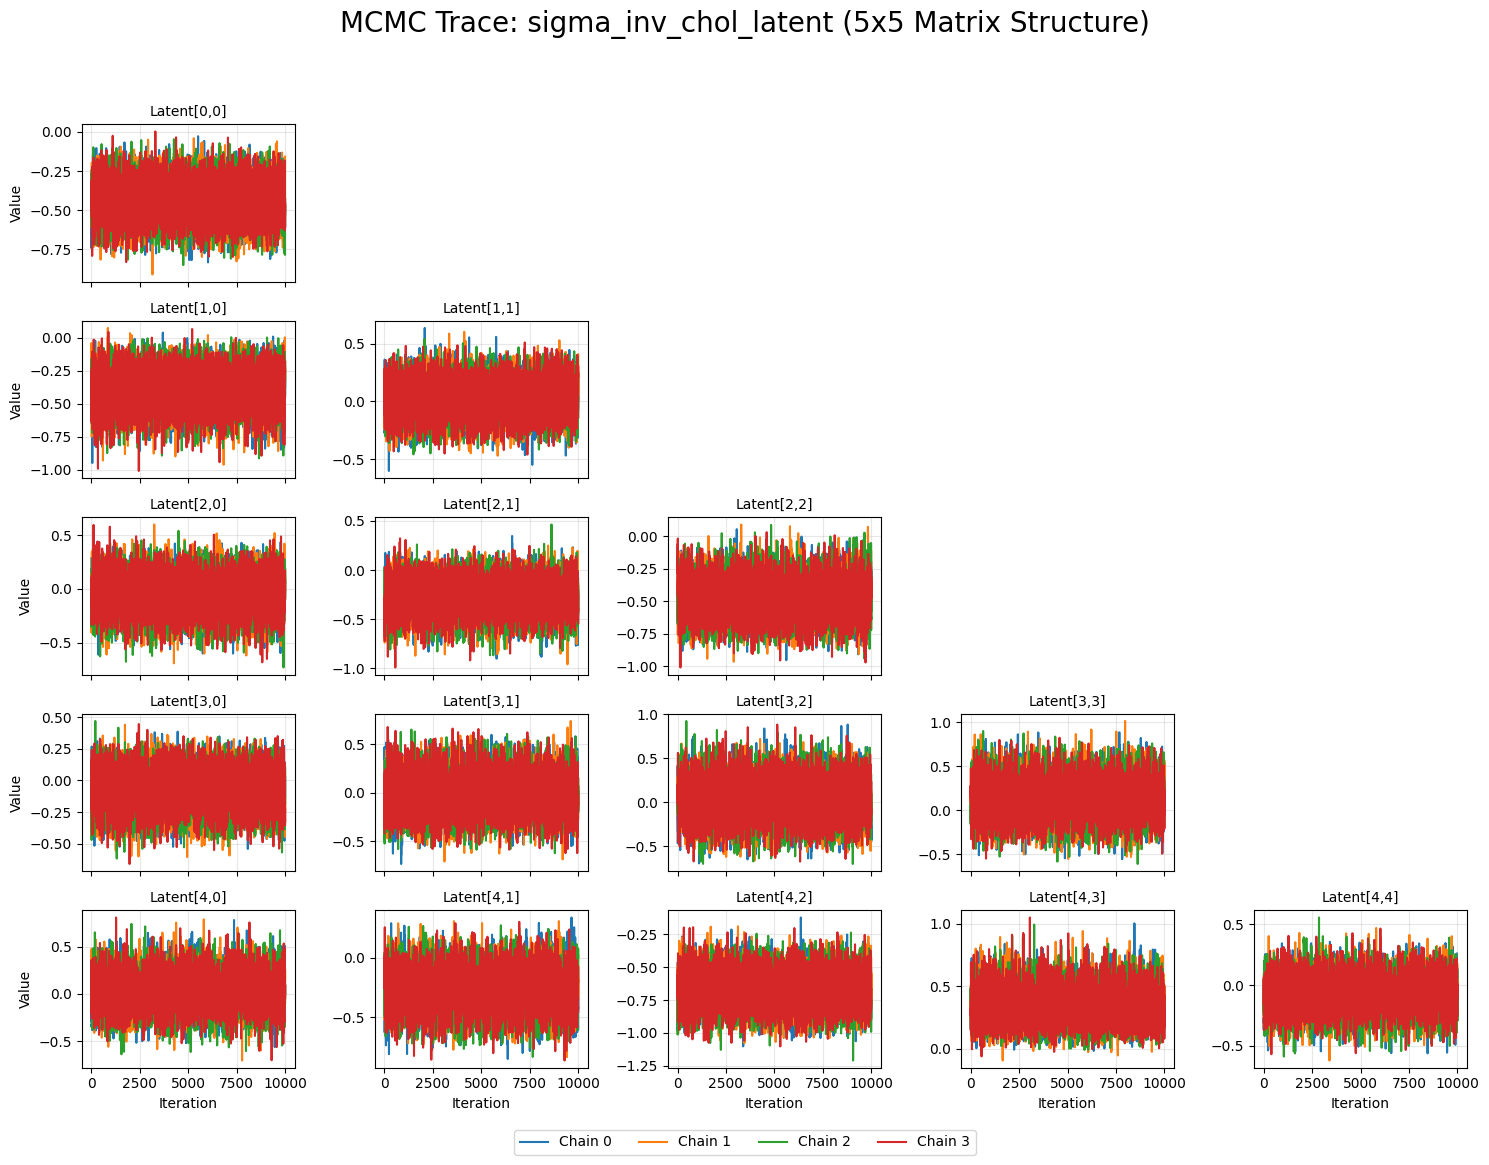

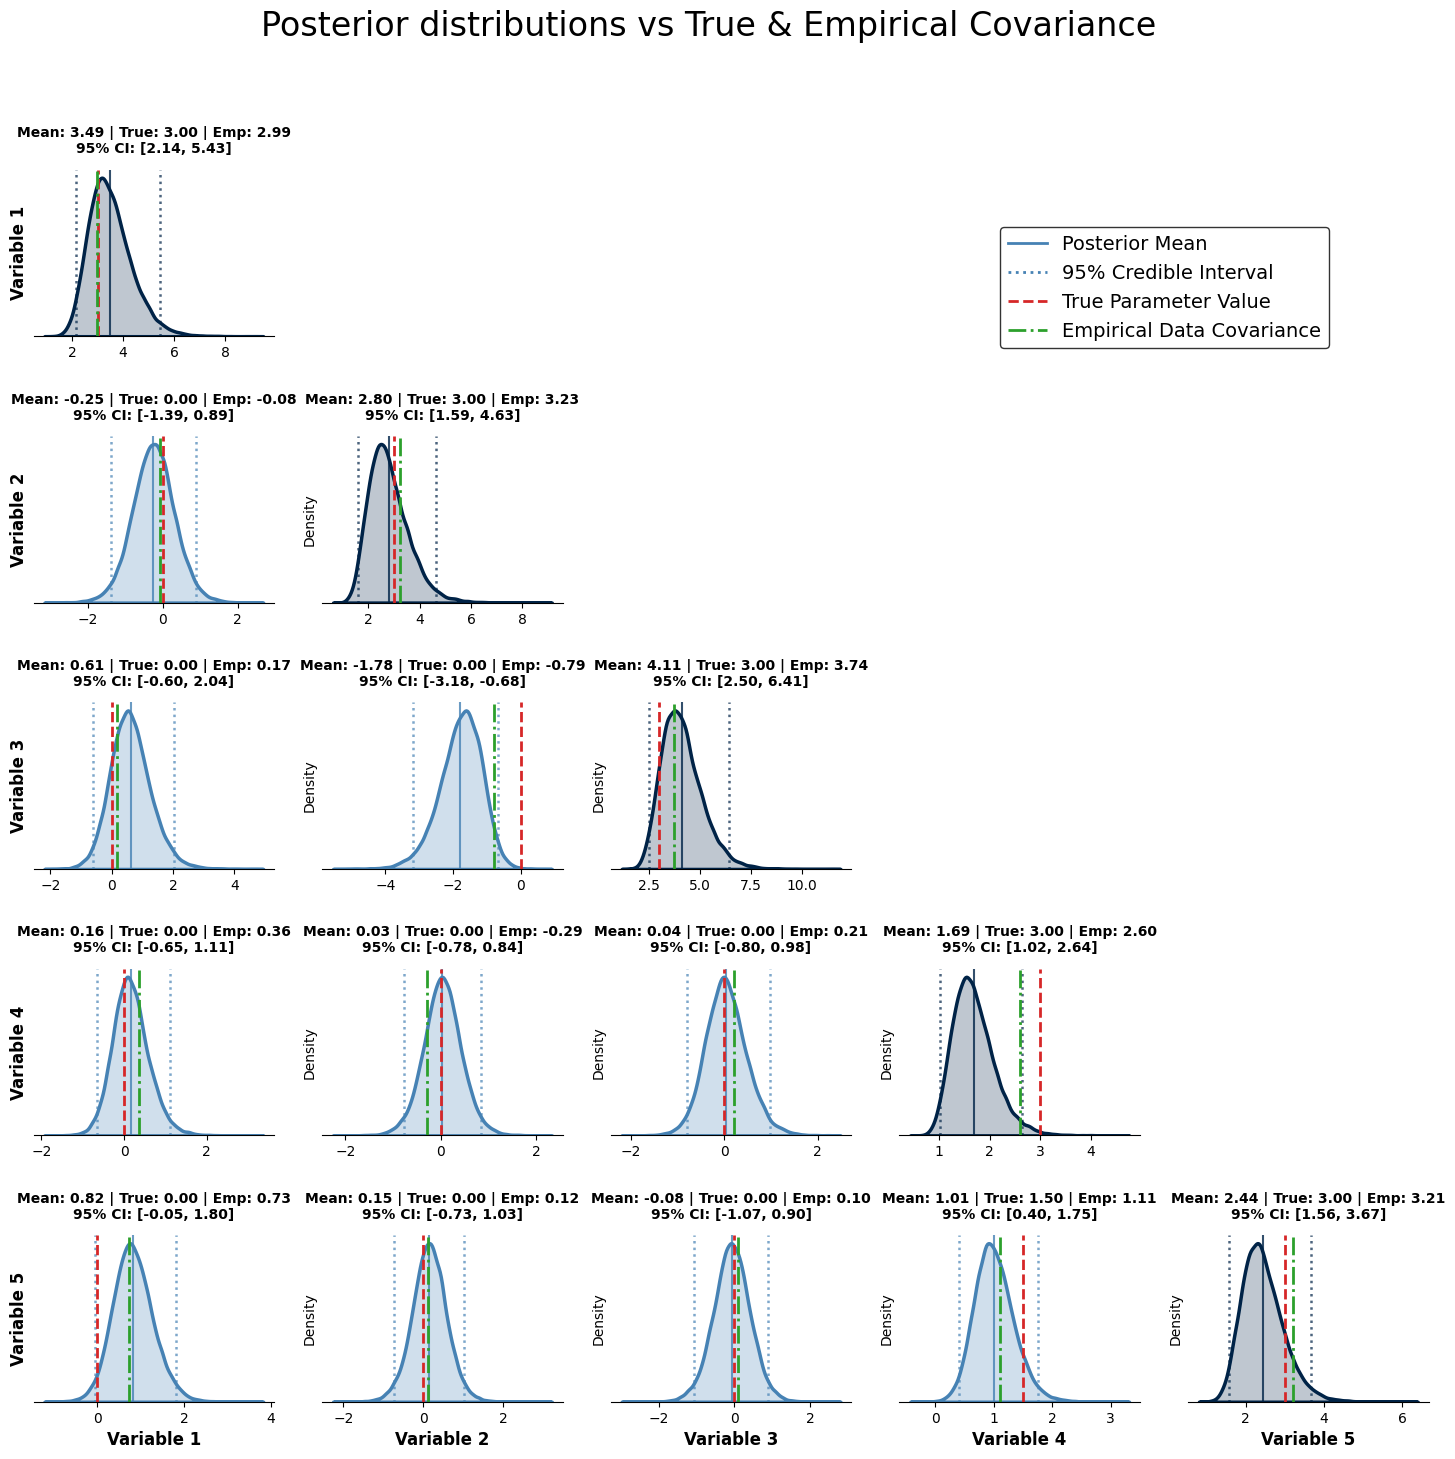

In [6]:
# ==================================
# ANALYTICS: Covariance Recovery
# ==================================
latent_samples = samples["sigma_inv_chol_latent"]
n_chains, n_draws, n_latent = latent_samples.shape

fig, axes = plt.subplots(5, 5, figsize=(15, 12), sharex=True, sharey=False)
latent_idx = 0
for i in range(5):
    for j in range(5):
        ax = axes[i, j]
        if i >= j and latent_idx < n_latent:
            for chain in range(n_chains):
                ax.plot(latent_samples[chain, :, latent_idx], alpha=1, label=f"Chain {chain}")
            ax.set_title(f"Latent[{i},{j}]", fontsize=10)
            latent_idx += 1
        else:
            ax.axis('off')
        ax.grid(True, alpha=0.3)
        if i == 4: ax.set_xlabel("Iteration")
        if j == 0: ax.set_ylabel("Value")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=n_chains, bbox_to_anchor=(0.5, 0.02))
plt.suptitle("MCMC Trace: sigma_inv_chol_latent (5x5 Matrix Structure)", fontsize=20)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

# Setup bijector mapping
bijector = tfb.FillScaleTriL(diag_bijector=tfb.Exp())
def latent_to_sigma(latent_vec):
    L = bijector.forward(latent_vec)
    precision_mat = L @ L.T
    return jnp.linalg.inv(precision_mat)

v_latent_to_sigma = jax.vmap(jax.vmap(latent_to_sigma))
sigma_samples = v_latent_to_sigma(latent_samples)
sigma_posterior_mean = jnp.mean(sigma_samples, axis=(0, 1))

def plot_final_covariance_complete(samples, true_matrix=None, empirical_matrix=None):
    n_dim = samples.shape[-1]
    fig, axes = plt.subplots(n_dim, n_dim, figsize=(18, 16))
    flattened_samples = samples.reshape(-1, n_dim, n_dim)
    
    diag_color = "#002347"  
    off_diag_color = "#4682B4"  
    true_val_color = "#D62728"  
    emp_val_color = "#2CA02C"  

    for i in range(n_dim):
        for j in range(n_dim):
            ax = axes[i, j]
            if j > i:
                ax.axis('off') 
                continue
            
            data_vec = flattened_samples[:, i, j]
            current_color = diag_color if i == j else off_diag_color
            
            post_mean = np.mean(data_vec)
            ci_low, ci_high = np.percentile(data_vec, [2.5, 97.5])
            sns.kdeplot(data_vec, ax=ax, fill=True, color=current_color, alpha=0.25, lw=2.5)
            
            ax.axvline(post_mean, color=current_color, linestyle="-", lw=1.5, alpha=0.8)
            ax.axvline(ci_low, color=current_color, linestyle=":", lw=1.8, alpha=0.7)
            ax.axvline(ci_high, color=current_color, linestyle=":", lw=1.8, alpha=0.7)
            
            title_parts = [f"Mean: {post_mean:.2f}"]
            if true_matrix is not None:
                ax.axvline(true_matrix[i, j], color=true_val_color, linestyle="--", lw=2)
                title_parts.append(f"True: {true_matrix[i, j]:.2f}")
            if empirical_matrix is not None:
                ax.axvline(empirical_matrix[i, j], color=emp_val_color, linestyle="-.", lw=2)
                title_parts.append(f"Emp: {empirical_matrix[i, j]:.2f}")

            ax.set_title(f"{' | '.join(title_parts)}\n95% CI: [{ci_low:.2f}, {ci_high:.2f}]", fontsize=10, pad=12, fontweight='bold')
            ax.set_yticks([])
            sns.despine(ax=ax, left=True)
            if i == n_dim - 1: ax.set_xlabel(f"Variable {j+1}", fontsize=12, fontweight='bold')
            if j == 0: ax.set_ylabel(f"Variable {i+1}", fontsize=12, fontweight='bold')

    legend_elements = [
        Line2D([0], [0], color=off_diag_color, linestyle='-',  lw=2, label='Posterior Mean'),
        Line2D([0], [0], color=off_diag_color, linestyle=':',  lw=2, label='95% Credible Interval'),
        Line2D([0], [0], color=true_val_color, linestyle='--', lw=2, label='True Parameter Value'),
        Line2D([0], [0], color=emp_val_color,  linestyle='-.', lw=2, label='Empirical Data Covariance')
    ]
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.85, 0.85), fontsize=14, frameon=True, edgecolor='black')
    plt.suptitle("Posterior distributions vs True & Empirical Covariance", fontsize=24, y=0.98, fontweight='light')
    plt.subplots_adjust(hspace=0.6, wspace=0.2)
    plt.show()

empirical_sigma = jnp.cov(data["true_betas"], rowvar=False)
plot_final_covariance_complete(sigma_samples, data["true_Sigma"], empirical_sigma)


=== Delta (Global Demographic Parameters) Summary ===
Shape: (3, 5) (covariates x parameters)

Posterior Means:
 [[ 1.331451   -0.9620363  -0.06598837  0.4642924  -2.8825035 ]
 [ 0.6085133   0.18603916 -0.30384743  0.05965005  0.7293496 ]
 [-0.75130445  0.24855842 -0.09874775 -0.3984426   0.0790638 ]]

True Means:
 [[ 1.  -1.   0.   0.  -3. ]
 [ 0.5  0.2 -0.1  0.   0.8]
 [-0.3  0.5  0.2 -0.4  0. ]]

=== Beta_i (Unit-Level Parameters) Summary ===

Unit-Level Parameter Recovery (All Parameters)


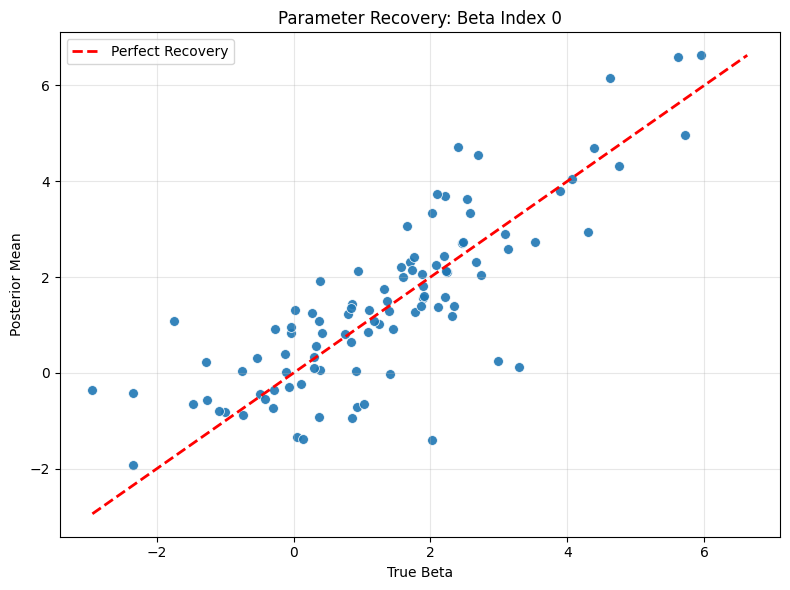

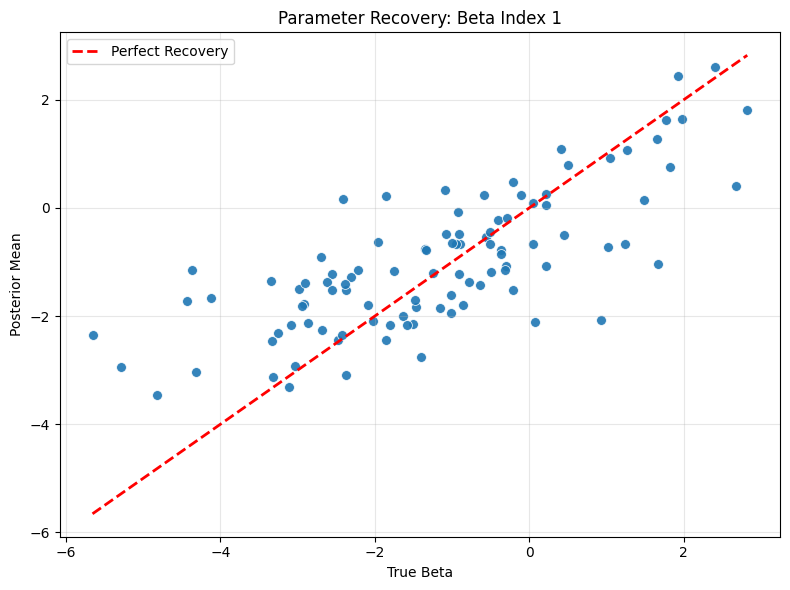

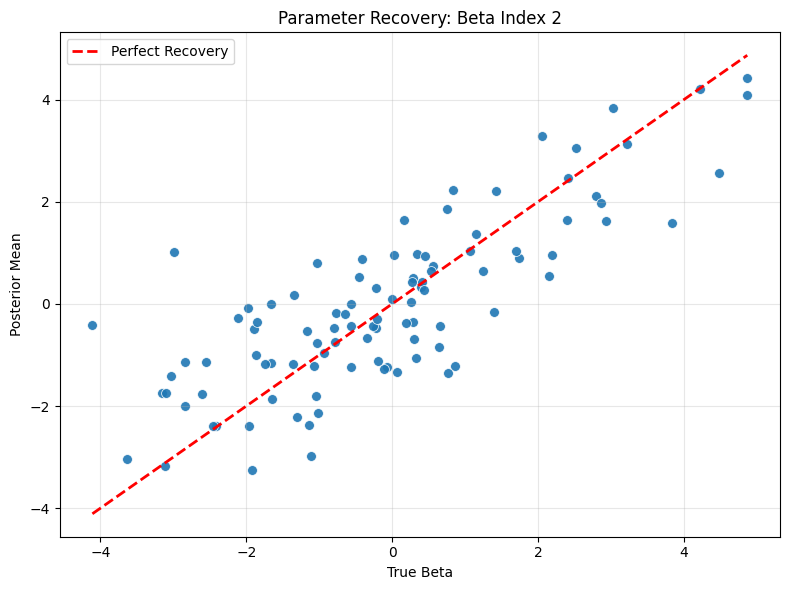

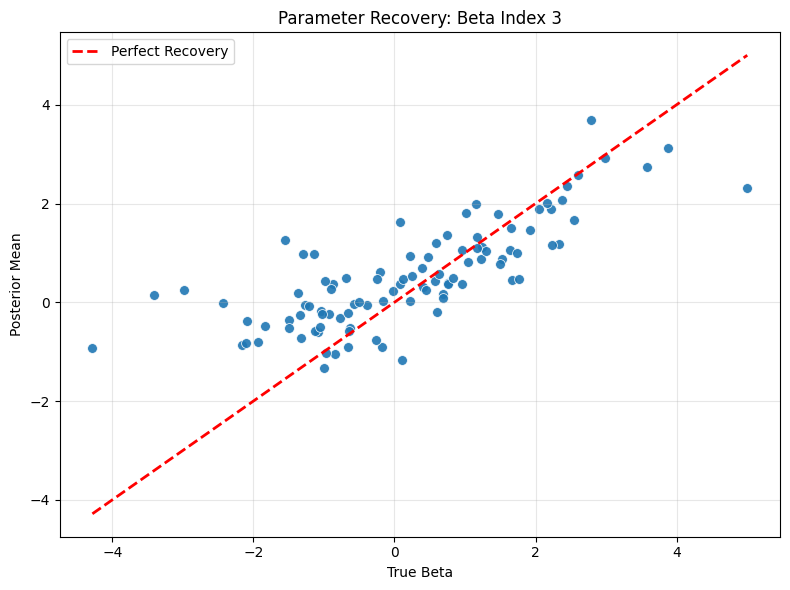

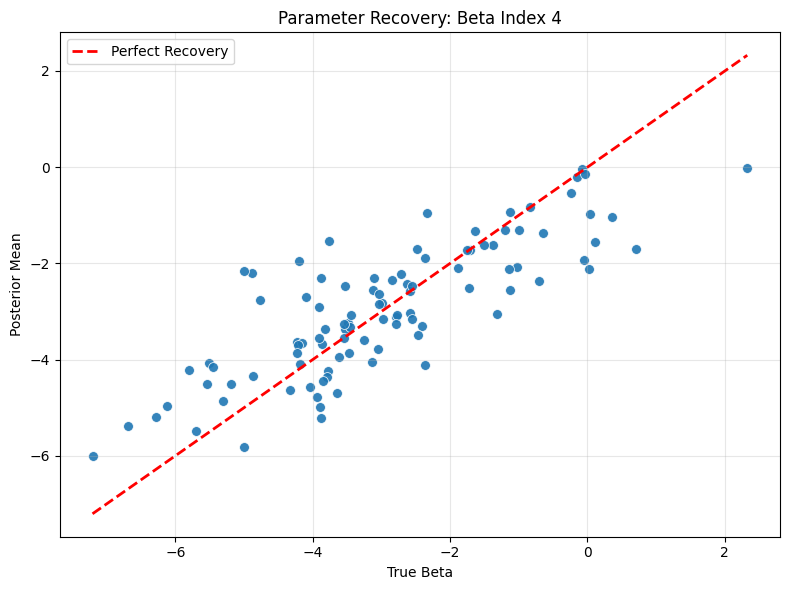

In [7]:
# ==================================
# ANALYTICS: Delta & Beta Statistics
# ==================================

print("\n=== Delta (Global Demographic Parameters) Summary ===")
delta_posterior_means = jnp.mean(samples["Delta"], axis=(0, 1))
delta_posterior_stds = jnp.std(samples["Delta"], axis=(0, 1))

print(f"Shape: {delta_posterior_means.shape} (covariates x parameters)")
print("\nPosterior Means:\n", delta_posterior_means)
print("\nTrue Means:\n", data["true_Delta"])

print("\n=== Beta_i (Unit-Level Parameters) Summary ===")
beta_posterior_means = jnp.mean(samples["beta_i"], axis=(0, 1)) 
beta_posterior_stds = jnp.std(samples["beta_i"], axis=(0, 1)) 

# Parameter Recovery (Beta_i)
print("\nUnit-Level Parameter Recovery (All Parameters)")
for param_idx in range(k_dim):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=data["true_betas"][:, param_idx], y=beta_posterior_means[:, param_idx], alpha=0.9, s=50)
    
    min_val = min(data["true_betas"][:, param_idx].min(), beta_posterior_means[:, param_idx].min())
    max_val = max(data["true_betas"][:, param_idx].max(), beta_posterior_means[:, param_idx].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label="Perfect Recovery")
    
    plt.xlabel("True Beta")
    plt.ylabel("Posterior Mean")
    plt.title(f"Parameter Recovery: Beta Index {param_idx}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



Boxplots (Posterior Ranges)


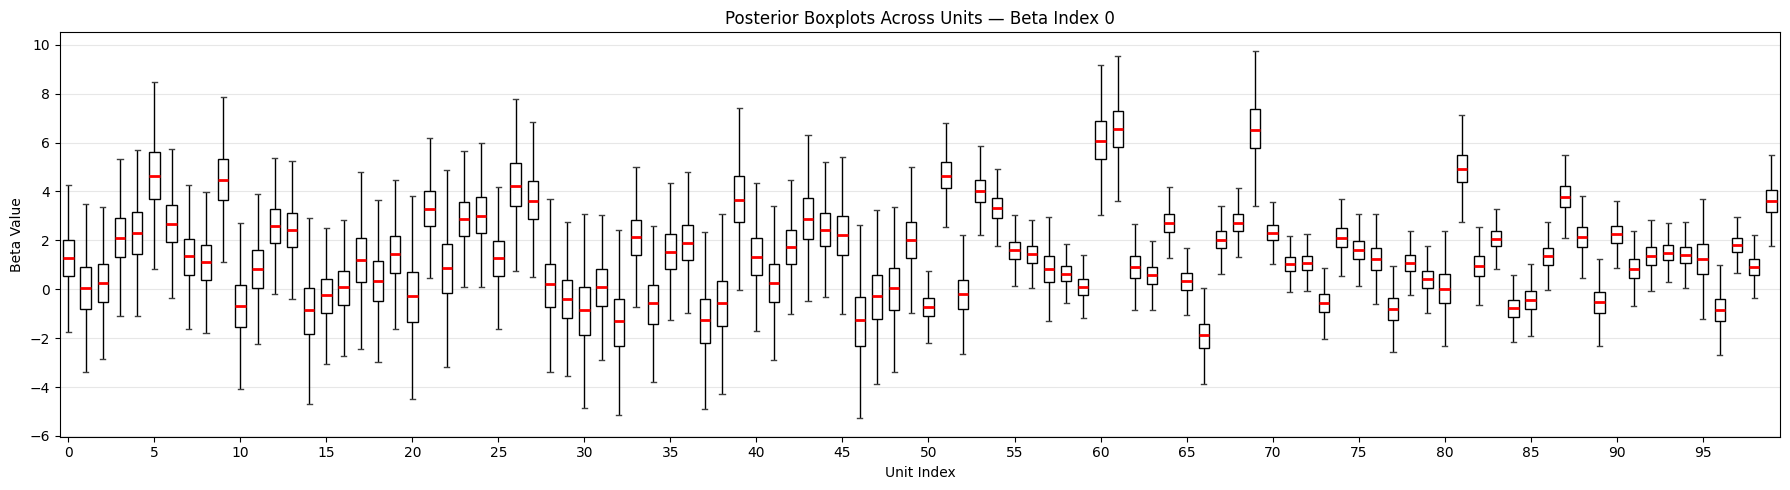

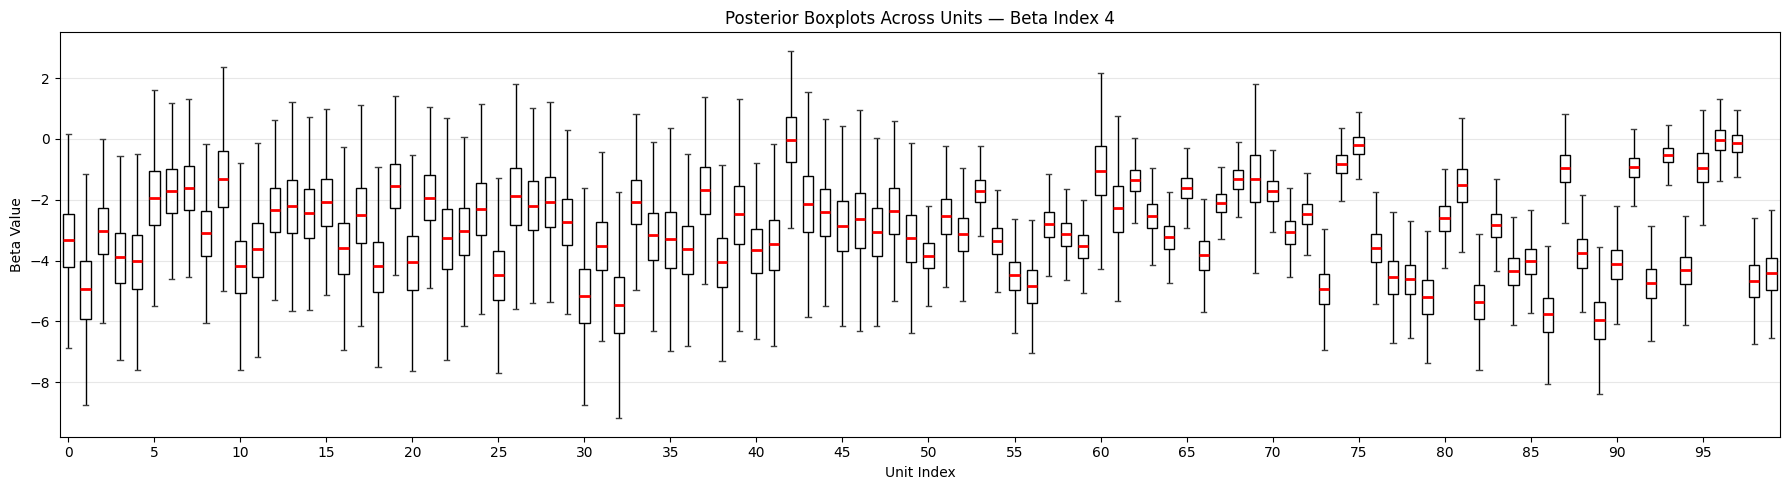


Faceted Posterior Distributions per Unit (Selected Parameters)


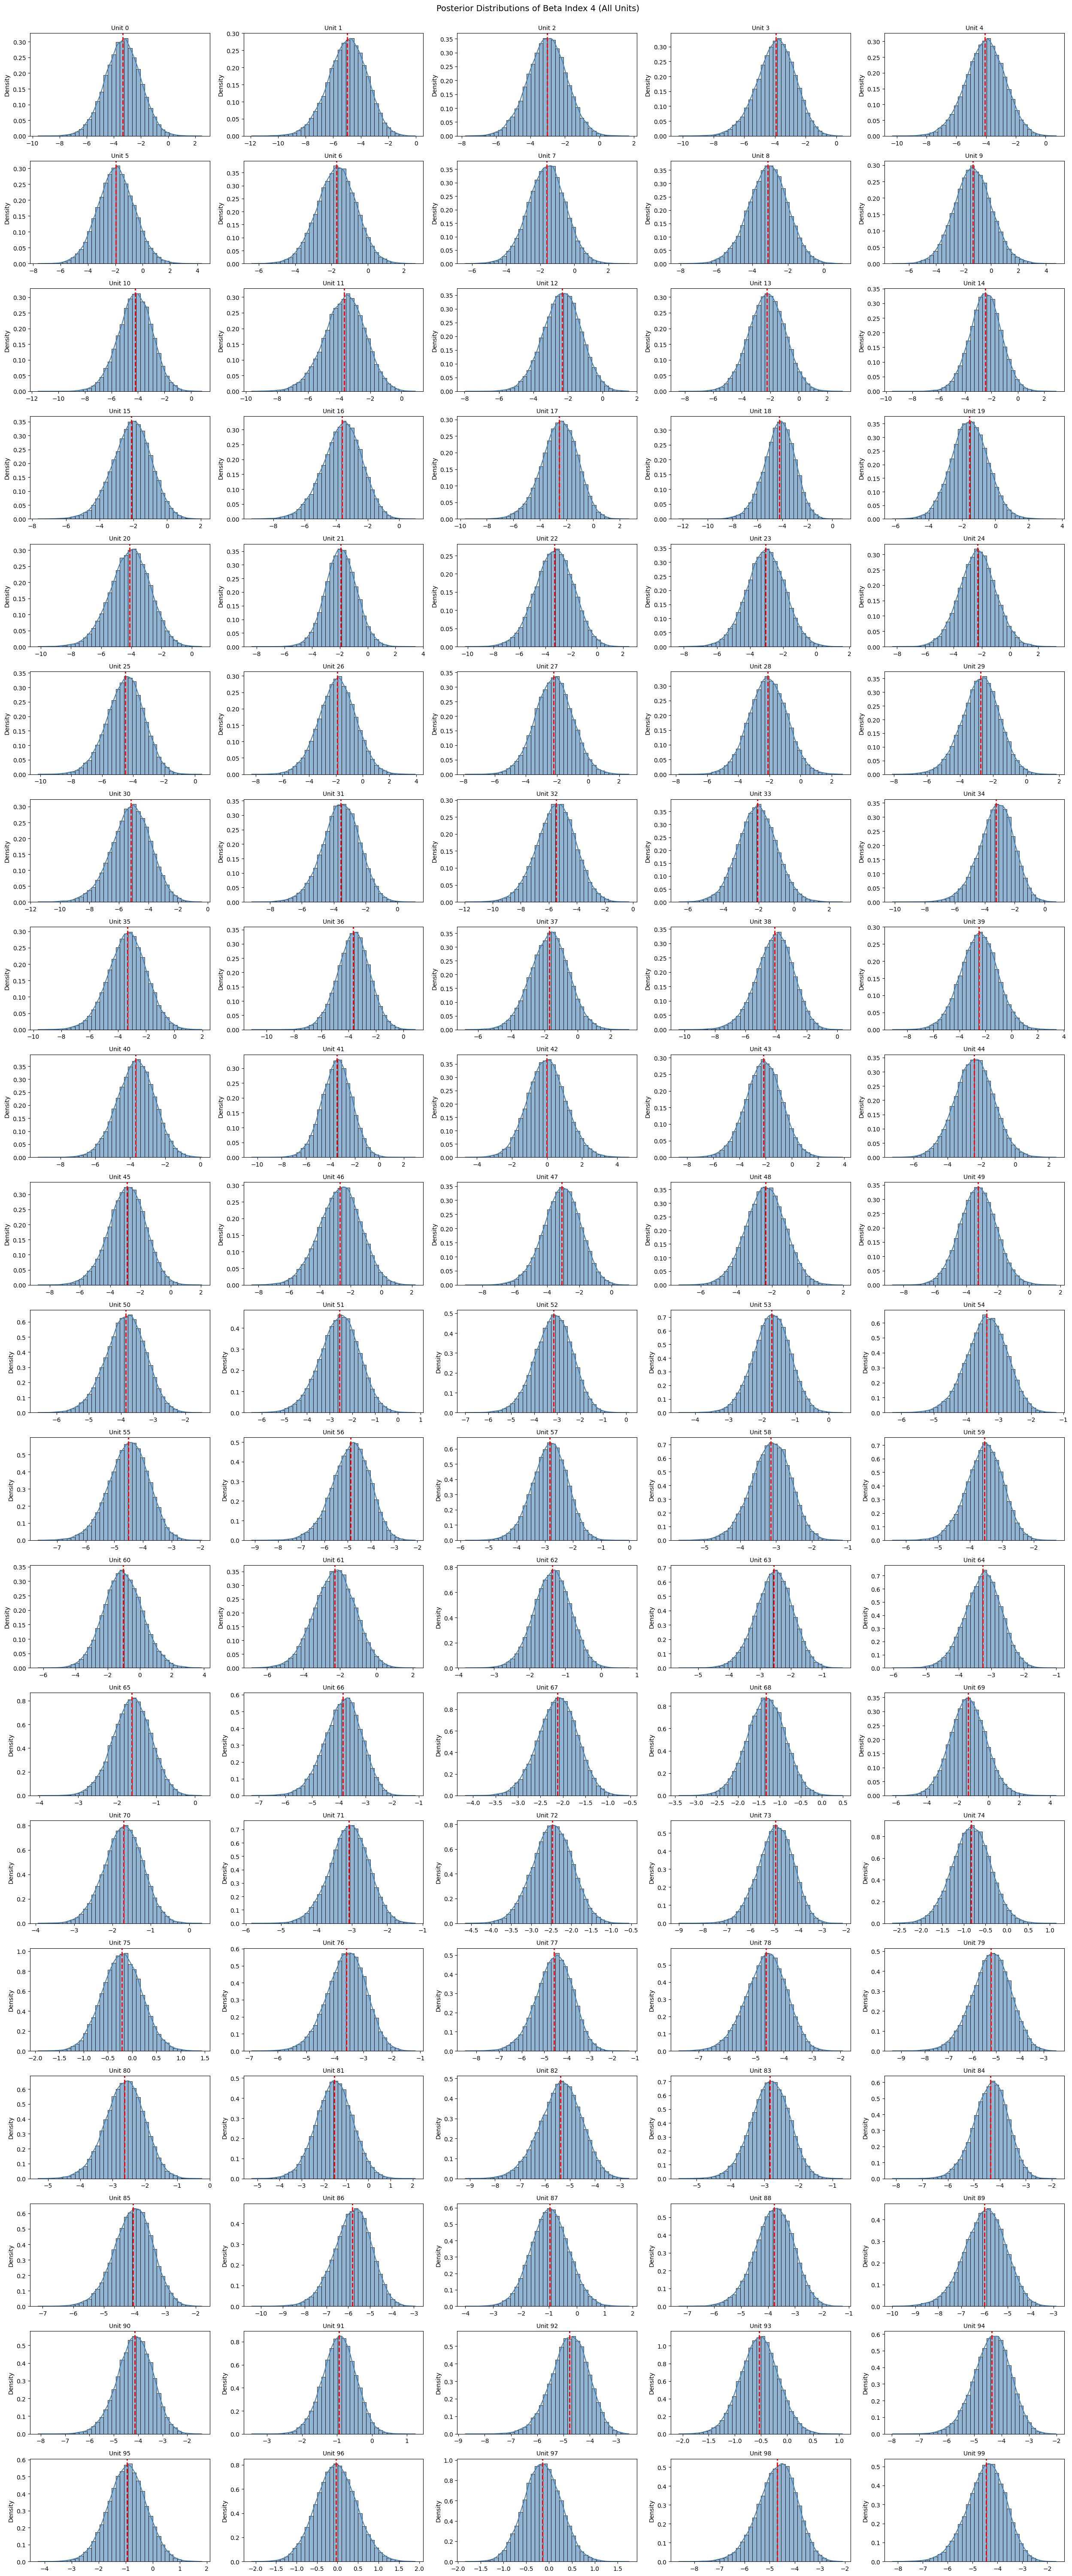


Overlay of Posterior Distributions


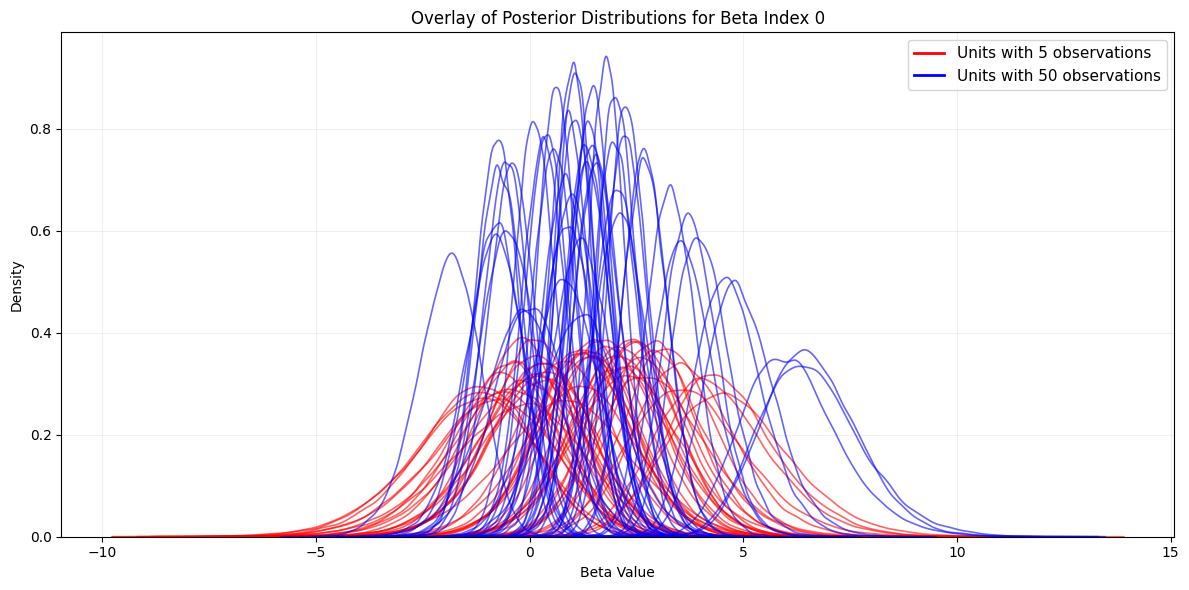

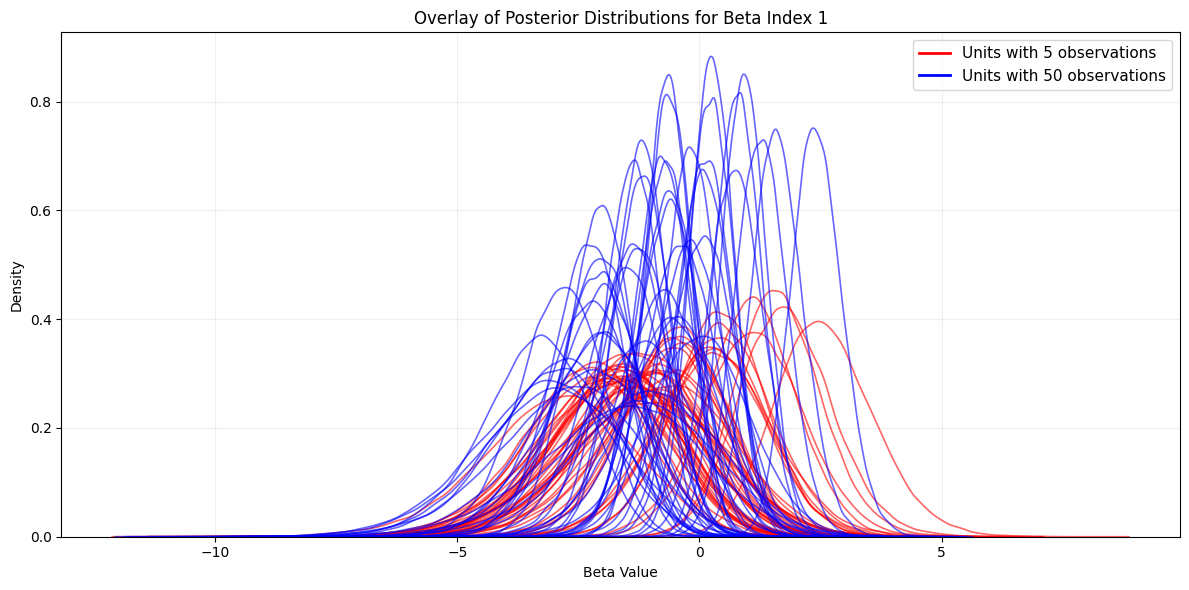

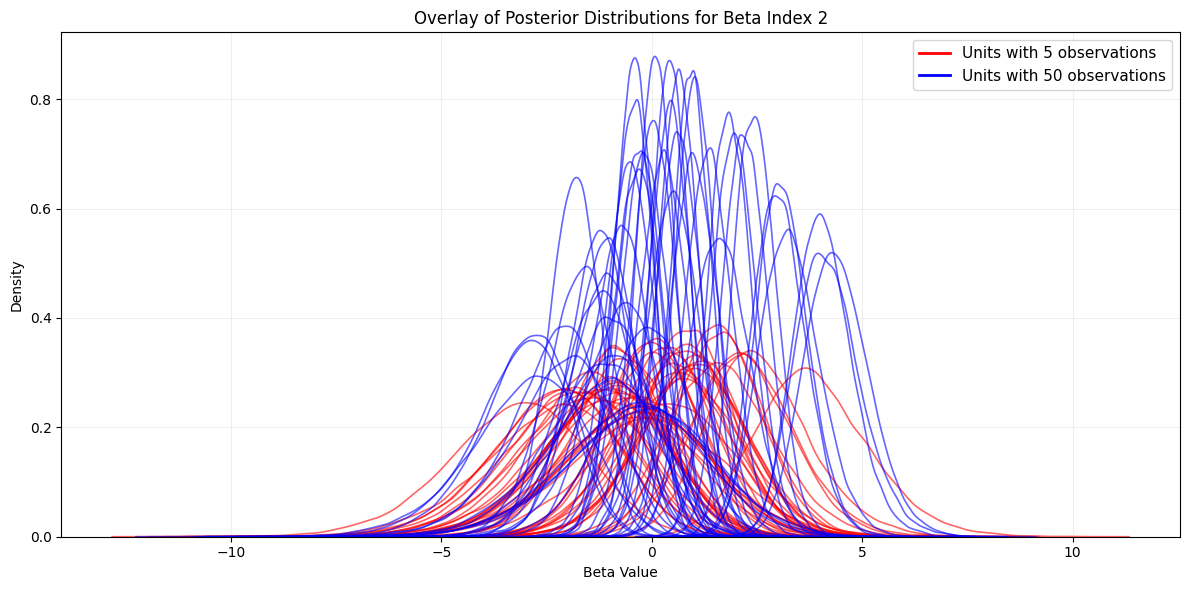

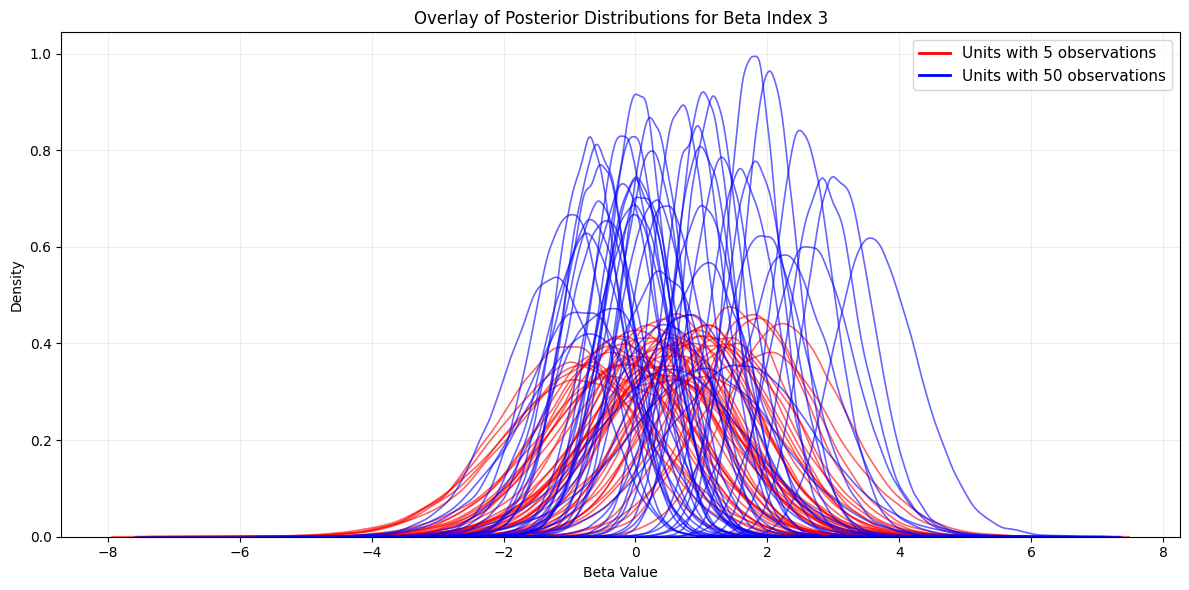

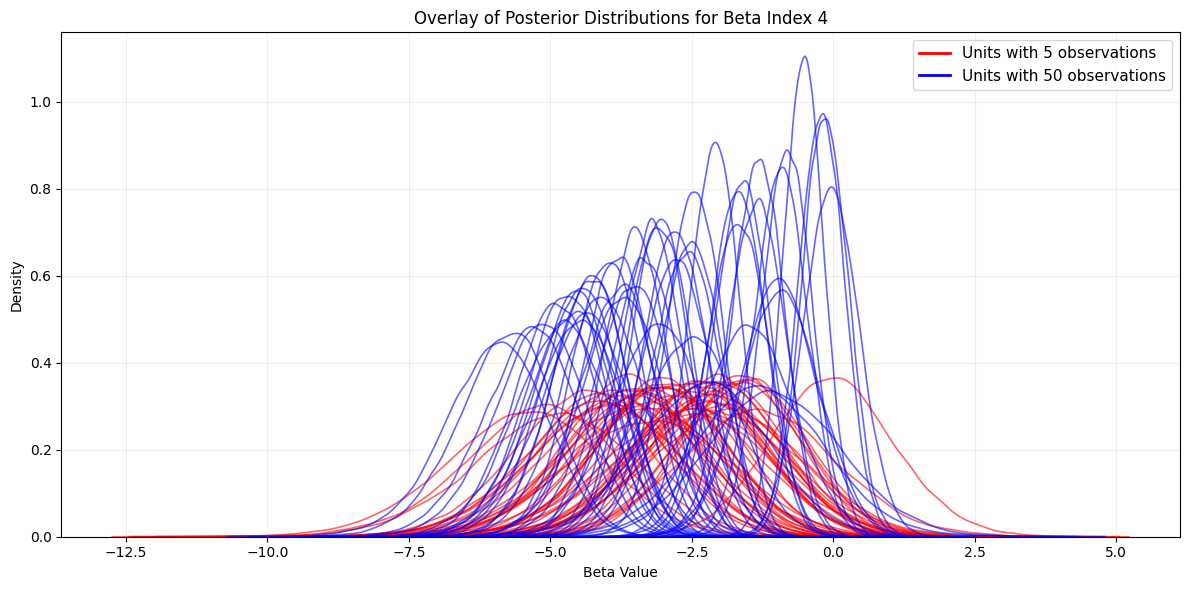


All Beta Indices (Pooled Across Units)


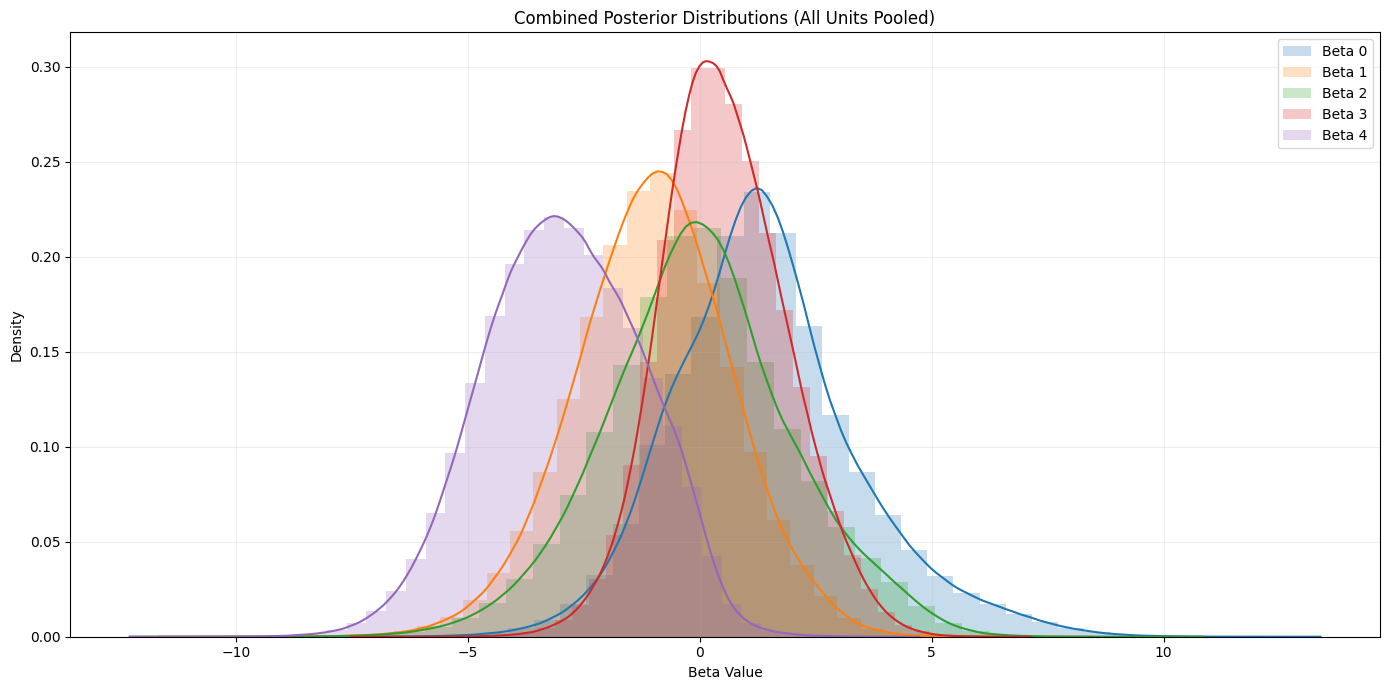

In [8]:
# =======================================
# POSTERIOR DISTRIBUTIONS
# =======================================

print("\nBoxplots (Posterior Ranges)")
def plot_unit_betas_boxplot(samples_dict, params=None, figsize=(18, 5)):
    beta_samps = samples_dict["beta_i"]
    n_params_total = beta_samps.shape[-1]
    if params is None: params = list(range(n_params_total))
    for param_idx in params:
        traces_2d = beta_samps[..., :, param_idx].reshape(-1, n_units)
        plt.figure(figsize=figsize)
        sns.boxplot(data=traces_2d, color="white", showcaps=True,
                    boxprops={'facecolor': 'white', 'edgecolor': 'black'},
                    whiskerprops={'color': 'black'}, medianprops={'color': 'red', 'linewidth': 2},
                    showfliers=False, width=0.6)
        plt.xticks(range(0, n_units, 5))
        plt.title(f"Posterior Boxplots Across Units — Beta Index {param_idx}")
        plt.xlabel("Unit Index")
        plt.ylabel("Beta Value")
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

plot_unit_betas_boxplot(samples, params=[0, 4]) 

print("\nFaceted Posterior Distributions per Unit (Selected Parameters)")
def plot_unit_beta_distributions(samples_dict, beta_index, bins=40):
    flat = samples_dict["beta_i"][..., :, beta_index].reshape(-1, n_units).T
    ncols = 5
    nrows = int(np.ceil(n_units / ncols))
    plt.figure(figsize=(5 * ncols, 3 * nrows))
    for unit in range(n_units):
        unit_samples = flat[unit]
        ax = plt.subplot(nrows, ncols, unit + 1)
        sns.histplot(unit_samples, bins=bins, kde=True, stat="density", alpha=0.6, color="steelblue", edgecolor="black")
        ax.axvline(np.mean(unit_samples), color='red', linestyle='--', linewidth=2)
        ax.set_title(f"Unit {unit}", fontsize=10)
    plt.suptitle(f"Posterior Distributions of Beta Index {beta_index} (All Units)", fontsize=14, y=1.00)
    plt.tight_layout()
    plt.show()

plot_unit_beta_distributions(samples, beta_index=4)

print("\nOverlay of Posterior Distributions")
def plot_all_units_overlay(samples_dict, beta_index):
    flat = samples_dict["beta_i"][..., :, beta_index].reshape(-1, n_units).T
    plt.figure(figsize=(12, 6))
    for unit in range(n_units):
        color = "red" if unit < 50 else "blue" # Red = 5 obs, Blue = 50 obs
        sns.kdeplot(flat[unit], linewidth=1.2, color=color, alpha=0.6)
    
    plt.plot([], [], color="red", linewidth=2, label="Units with 5 observations")
    plt.plot([], [], color="blue", linewidth=2, label="Units with 50 observations")
    plt.legend(fontsize=11)
    plt.title(f"Overlay of Posterior Distributions for Beta Index {beta_index}")
    plt.xlabel("Beta Value")
    plt.ylabel("Density")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

for param_idx in range(k_dim):
    plot_all_units_overlay(samples, param_idx)

print("\nAll Beta Indices (Pooled Across Units)")
plt.figure(figsize=(14, 7))
for b in range(k_dim):
    arr = samples["beta_i"][..., b].reshape(-1) 
    sns.histplot(arr, bins=40, kde=True, stat="density", alpha=0.25, linewidth=0, label=f"Beta {b}")
plt.title("Combined Posterior Distributions (All Units Pooled)")
plt.xlabel("Beta Value")
plt.ylabel("Density")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()